### KNN - Exercises 

#### Imports

In [2]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import mlflow 
import os

In [4]:
df = pd.read_csv("../dataset/dataset_treino_knn.csv")
df.head()

,x0,y0,x1,y1,x2,y2,x3,y3,x4,y4,...,x13,y13,x14,y14,x15,y15,x16,y16,label,exercicio
0,0.338861,0.246909,0.361513,0.232695,0.325735,0.234862,0.423863,0.242564,0.340954,0.246080,...,0.540450,0.720815,0.447457,0.723837,0.533332,0.897908,0.461125,0.897138,0,Bicep Curl
1,0.343579,0.248057,0.367473,0.233306,0.331372,0.235366,0.434262,0.241191,0.349794,0.245026,...,0.544844,0.720798,0.448322,0.724789,0.545403,0.895726,0.465810,0.895121,0,Bicep Curl
2,0.348915,0.248230,0.373390,0.233397,0.336912,0.235384,0.441305,0.241068,0.355477,0.244784,...,0.543155,0.720601,0.445984,0.724068,0.545200,0.896568,0.465814,0.895841,0,Bicep Curl
3,0.361257,0.244620,0.386626,0.229889,0.349152,0.231668,0.454018,0.238348,0.365574,0.241550,...,0.541443,0.720312,0.441855,0.723030,0.545325,0.896268,0.464889,0.895324,0,Bicep Curl
4,0.373642,0.244610,0.398362,0.230382,0.360549,0.232074,0.462739,0.239414,0.373565,0.242348,...,0.540000,0.719290,0.440182,0.720099,0.538103,0.899256,0.463436,0.897229,0,Bicep Curl


In [5]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("SVM Pose Classifier - V2")

exercise_map = {
    'Bicep Curl': 0,
    'Front Raise': 2,
    'Shoulder Press': 4
}

def create_compound_label(row):
    base_id = exercise_map.get(row['exercicio'])
    return base_id + row['label']

with mlflow.start_run(run_name="Experiment - Multiclass"):

    df['target'] = df.apply(create_compound_label, axis=1)

    print("Classes geradas (Target):")
    print(df[['exercicio', 'label', 'target']].drop_duplicates().sort_values('target'))

    X = df.drop(columns=['label', 'exercicio', 'target']) 
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print("\nTreinando modelo unificado...")
    model = svm.SVC(kernel='rbf', C=10.0, gamma='scale', probability=True)
    model.fit(X_train, y_train)

    print("\nPerformance do Modelo Único:")
    print(classification_report(y_test, model.predict(X_test)))

    initial_type = [('input', FloatTensorType([None, X_train.shape[1]]))]

    onnx_model = convert_sklearn(model, initial_types=initial_type)
    
    onnx_filename = "modelo_unico.onnx"
    with open(onnx_filename, "wb") as f:
        f.write(onnx_model.SerializeToString())
    
    print(f"Sucesso! '{onnx_filename}' gerado para o Go.")

    mlflow.sklearn.log_model(model, "SVM_model")
    print("Treino concluído!")

Classes geradas (Target):
            exercicio  label  target
0          Bicep Curl      0       0
4330       Bicep Curl      1       1
15153     Front Raise      0       2
17790     Front Raise      1       3
31689  Shoulder Press      0       4
33571  Shoulder Press      1       5

Treinando modelo unificado...

Performance do Modelo Único:


2026/01/18 21:53:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2541
           1       0.99      0.97      0.98       490
           2       0.93      0.99      0.96      2672
           3       0.96      0.70      0.81       635
           4       1.00      1.00      1.00      2148
           5       1.00      1.00      1.00       651

    accuracy                           0.97      9137
   macro avg       0.98      0.94      0.96      9137
weighted avg       0.98      0.97      0.97      9137

Sucesso! 'modelo_unico.onnx' gerado para o Go.
Treino concluído!
🏃 View run Experiment - Multiclass at: http://127.0.0.1:5000/#/experiments/3/runs/07b1f889336340b0a4abb493f687b2c3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Calculando ângulos para o gráfico...


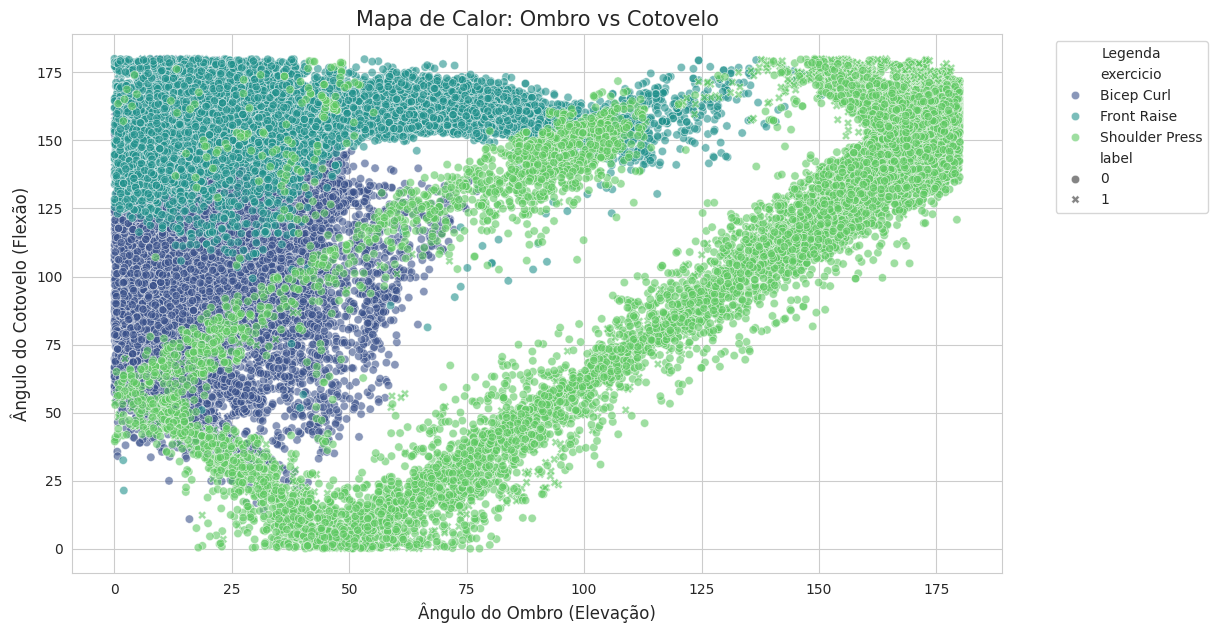

In [6]:
def calculate_angle_notebook(ax, ay, bx, by, cx, cy):
    ba = np.array([ax - bx, ay - by])
    bc = np.array([cx - bx, cy - by])
    
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))
    return angle

print("Calculando ângulos para o gráfico...")
df['ang_cotovelo'] = df.apply(lambda r: calculate_angle_notebook(r.x5, r.y5, r.x7, r.y7, r.x9, r.y9), axis=1)
df['ang_ombro'] = df.apply(lambda r: calculate_angle_notebook(r.x11, r.y11, r.x5, r.y5, r.x7, r.y7), axis=1)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    data=df, 
    x='ang_ombro', 
    y='ang_cotovelo', 
    hue='exercicio', 
    style='label',
    alpha=0.6, 
    palette='viridis'
)

plt.title('Mapa de Calor: Ombro vs Cotovelo', fontsize=15)
plt.xlabel('Ângulo do Ombro (Elevação)', fontsize=12)
plt.ylabel('Ângulo do Cotovelo (Flexão)', fontsize=12)
plt.legend(title='Legenda', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()